# Chocolate Sales: 2024 Forecast and Product/Channel Portfolio

**Goal:** Predict 2024 sales for a chocolate distributor and recommend which product and which sales channel look like the weakest candidates to drop

In [2]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt

from src import config, data_loader, preprocessing, train, forecast, analyze

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (9, 4.5)

In [3]:
raw_df = data_loader.load_raw_data()
print(raw_df.shape)
raw_df.head()

(200000, 11)


,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
0,ORD-069833,Truffle Gift Box,Australia,Retail,Arjun Mehta,2022-12-11,3.50,13.72,202.03,71,912.31
1,ORD-090726,85% Dark Bar,Australia,Retail,Arjun Mehta,2023-03-14,9.40,3.30,55.18,84,245.91
2,ORD-042159,70% Dark Bar,Japan,Retail,Hannah Müller,2023-12-21,4.90,18.21,60.65,35,583.7
3,ORD-197166,Hazelnut Milk Bar,Germany,Retail,Arjun Mehta,2023-12-18,15.00,2.66,52.00,92,211.27
4,ORD-112162,Almond Crunch Bar,Australia,Retail,Yuki Sato,2023-08-18,4.40,2.75,187.44,214,549.69


In [4]:
raw_df.isna().sum()

Order_ID             0
Product              0
Country              0
Channel              0
Salesperson          0
Order_Date         437
Discount_Pct       489
Price_per_Box      457
Marketing_Spend    461
Boxes_Shipped        0
Amount               0
dtype: int64

In [5]:
print("Rows with a $ in Amount:", raw_df['Amount'].astype(str).str.contains(r'\$').sum())
print("Rows with negative Boxes_Shipped:", (raw_df['Boxes_Shipped'] < 0).sum())
non_iso = raw_df['Order_Date'].dropna().astype(str)
non_iso = non_iso[~non_iso.str.match(r'^\d{4}-\d{2}-\d{2}$')]
print("Rows with a non-ISO date:", len(non_iso))
non_iso.head()

Rows with a $ in Amount: 2750
Rows with negative Boxes_Shipped: 1956
Rows with a non-ISO date: 2886


256    12-03-2023
304    09/02/2022
350    02/06/2023
379    02-12-2023
427    20/01/2022
Name: Order_Date, dtype: object

#Data cleaning

In [6]:
clean_df = preprocessing.clean_data(raw_df)
print(f"Raw rows:   {len(raw_df):,}")
print(f"Clean rows: {len(clean_df):,}  ({len(raw_df) - len(clean_df):,} dropped -- "
      "unparseable dates or missing Amount)")
clean_df.isna().sum().sum(), clean_df.head()

Raw rows:   200,000
Clean rows: 199,556  (444 dropped -- unparseable dates or missing Amount)


(0,
      Order_ID            Product    Country Channel    Salesperson Order_Date  \
 0  ORD-069833   Truffle Gift Box  Australia  Retail    Arjun Mehta 2022-12-11   
 1  ORD-090726       85% Dark Bar  Australia  Retail    Arjun Mehta 2023-03-14   
 2  ORD-042159       70% Dark Bar      Japan  Retail  Hannah Müller 2023-12-21   
 3  ORD-197166  Hazelnut Milk Bar    Germany  Retail    Arjun Mehta 2023-12-18   
 4  ORD-112162  Almond Crunch Bar  Australia  Retail      Yuki Sato 2023-08-18   
 
    Discount_Pct  Price_per_Box  Marketing_Spend  Boxes_Shipped  Amount  Year  \
 0          3.50          13.72           202.03             71  912.31  2022   
 1          9.40           3.30            55.18             84  245.91  2023   
 2          4.90          18.21            60.65             35  583.70  2023   
 3         15.00           2.66            52.00             92  211.27  2023   
 4          4.40           2.75           187.44            214  549.69  2023   
 
    Month  Qua

Analysis


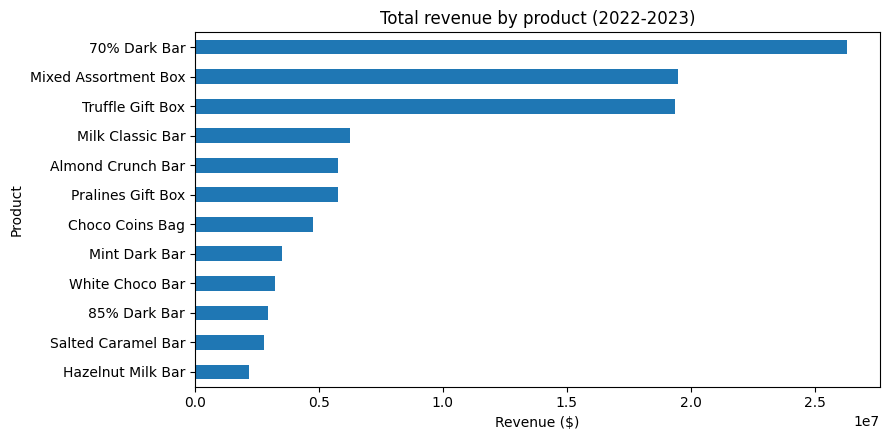

In [7]:
rev_by_product = clean_df.groupby("Product")["Amount"].sum().sort_values()
rev_by_product.plot(kind="barh", title="Total revenue by product (2022-2023)")
plt.xlabel("Revenue ($)")
plt.tight_layout()
plt.show()

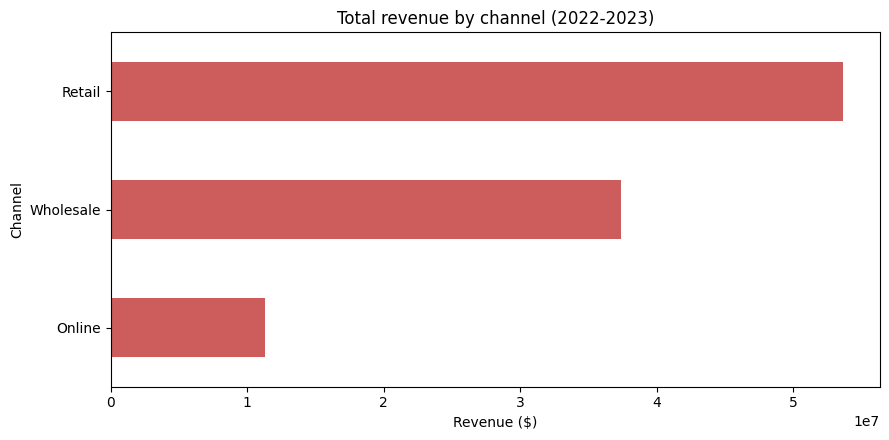

In [8]:
rev_by_channel = clean_df.groupby("Channel")["Amount"].sum().sort_values()
rev_by_channel.plot(kind="barh", title="Total revenue by channel (2022-2023)", color="indianred")
plt.xlabel("Revenue ($)")
plt.tight_layout()
plt.show()

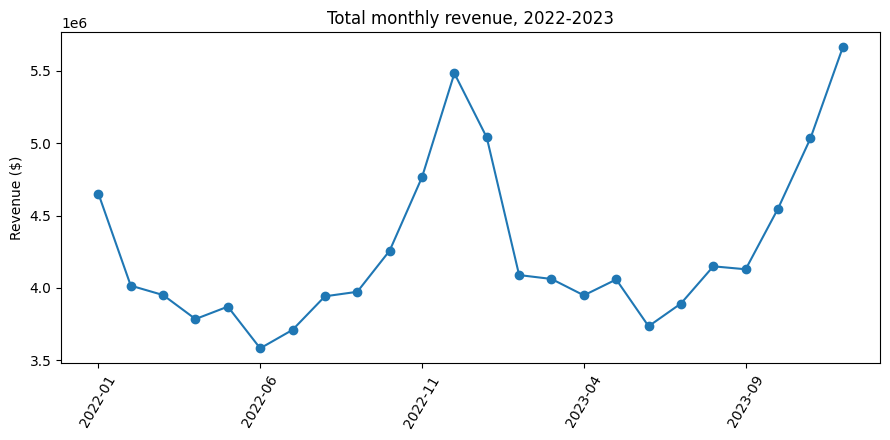

In [9]:
monthly = clean_df.groupby(["Year", "Month"])["Amount"].sum()
monthly.index = [f"{y}-{m:02d}" for y, m in monthly.index]
monthly.plot(kind="line", marker="o", title="Total monthly revenue, 2022-2023")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

Training model

In [10]:
result = train.train_and_select_best(clean_df)

leaderboard = pd.DataFrame(result["leaderboard"]).set_index("model")
leaderboard[["MAE", "RMSE", "MAPE", "R2", "CV_RMSE_mean", "train_seconds"]]

,MAE,RMSE,MAPE,R2,CV_RMSE_mean,train_seconds
model,,,,,,
linear_regression,117.57,244.23,17.64,0.71,180.81,0.14
ridge,117.63,244.21,17.66,0.71,180.81,0.12
random_forest,42.81,140.44,6.11,0.90,120.65,6.59
hist_gradient_boosting,48.17,150.25,6.66,0.89,124.86,0.95


In [11]:
best_name = result["best"]["name"]
best_pipeline = result["best"]["pipeline"]
print(f"Selected model: {best_name}")
print(result["best"]["metrics"])

Selected model: random_forest
{'MAE': 42.81486544108394, 'RMSE': 140.43517865069597, 'MAPE': 6.106668105616776, 'R2': 0.9030270641484087, 'CV_RMSE_mean': 120.64988939284562, 'CV_RMSE_std': 20.510721180359536, 'train_seconds': 6.59}


In [12]:
train.save_model(best_pipeline, best_name, result["best"]["metrics"])
print(f"Saved to {config.MODEL_PATH}")

Saved to /Users/shelciamuianga/chocolate-sales-prediction/models/sales_model.joblib


Forecast 2024

In [13]:
scored_flat = forecast.predict_2024(best_pipeline, clean_df, scenario="flat")
scored_trend = forecast.predict_2024(best_pipeline, clean_df, scenario="trend")

total_2023 = clean_df.loc[clean_df["Year"] == 2023, "Amount"].sum()
total_2024_flat = scored_flat["Predicted_Amount"].sum()
total_2024_trend = scored_trend["Predicted_Amount"].sum()

print(f"2023 actual revenue:              ${total_2023:,.0f}")
print(f"2024 predicted revenue (flat):     ${total_2024_flat:,.0f}  "
      f"({(total_2024_flat/total_2023 - 1)*100:+.1f}%)")
print(f"2024 predicted revenue (trend):    ${total_2024_trend:,.0f}  "
      f"({(total_2024_trend/total_2023 - 1)*100:+.1f}%)")

2023 actual revenue:              $52,346,522
2024 predicted revenue (flat):     $52,234,191  (-0.2%)
2024 predicted revenue (trend):    $54,838,182  (+4.8%)


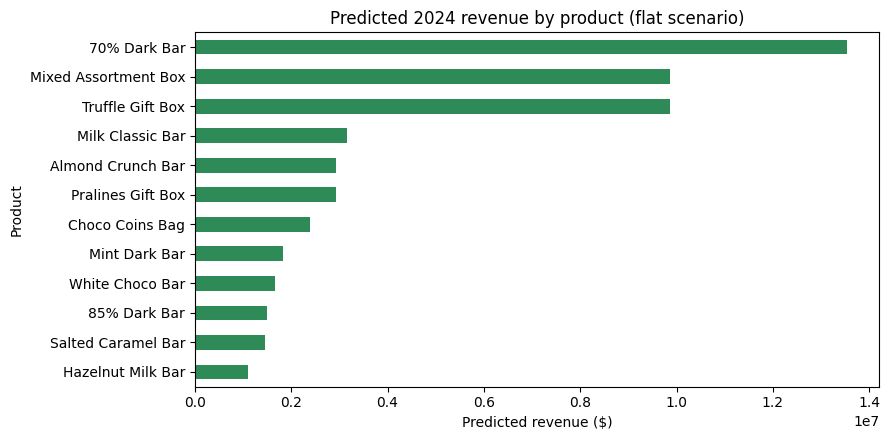

In [14]:
product_summary_flat = forecast.summarize_forecast(scored_flat, "Product")
product_summary_flat.set_index("Product")["Predicted_2024_Revenue"].sort_values().plot(
    kind="barh", title="Predicted 2024 revenue by product (flat scenario)", color="seagreen"
)
plt.xlabel("Predicted revenue ($)")
plt.tight_layout()
plt.show()

Which product should be dropped?

In [15]:
channel_summary_flat = forecast.summarize_forecast(scored_flat, "Channel")

ranked_products = analyze.rank_performers(clean_df, product_summary_flat, "Product")
ranked_channels = analyze.rank_performers(clean_df, channel_summary_flat, "Channel")

ranked_products[[
    "Product", "Predicted_2024_Revenue", "YoY_Growth_2022_to_2023",
    "Marketing_ROI_2023", "composite_score"
]]

,Product,Predicted_2024_Revenue,YoY_Growth_2022_to_2023,Marketing_ROI_2023,composite_score
0,85% Dark Bar,"1,489,193.04",-0.01,3.98,2.00
1,Hazelnut Milk Bar,"1,092,897.63",0.01,4.39,2.67
2,Milk Classic Bar,"3,162,206.94",0.02,4.15,5.00
3,Mint Dark Bar,"1,833,081.02",0.06,3.62,5.33
4,Pralines Gift Box,"2,933,879.76",0.03,4.84,6.00
5,White Choco Bar,"1,669,856.57",0.07,4.78,7.00
6,Salted Caramel Bar,"1,465,302.44",0.10,5.19,7.33
7,70% Dark Bar,"13,529,306.69",0.05,4.39,7.67
8,Almond Crunch Bar,"2,934,314.08",0.04,6.81,7.67
9,Choco Coins Bag,"2,394,123.63",0.05,8.10,8.67


In [16]:
ranked_channels[[
    "Channel", "Predicted_2024_Revenue", "YoY_Growth_2022_to_2023",
    "Marketing_ROI_2023", "composite_score"
]]

,Channel,Predicted_2024_Revenue,YoY_Growth_2022_to_2023,Marketing_ROI_2023,composite_score
0,Online,"5,756,464.32",0.04,5.05,1.33
1,Retail,"27,509,384.35",0.05,4.97,2.33
2,Wholesale,"18,968,342.52",0.05,6.78,2.33


In [17]:
print(analyze.recommend_drops(ranked_products, "Product", n=2))
print()
print(analyze.recommend_drops(ranked_channels, "Channel", n=1))

Lowest-ranked product(s), candidates to discontinue:
  - 85% Dark Bar: predicted 2024 revenue $1,489,193, 2022->2023 growth -1.0%, marketing ROI 3.98x
  - Hazelnut Milk Bar: predicted 2024 revenue $1,092,898, 2022->2023 growth 1.3%, marketing ROI 4.39x

Lowest-ranked channel(s), candidates to discontinue:
  - Online: predicted 2024 revenue $5,756,464, 2022->2023 growth 4.1%, marketing ROI 5.05x


## 8. Summary

- **Problem type:** supervised regression (predict order revenue), used as
  the engine behind a forecasting + decision-support workflow.
- **Best model:** selected by time-based holdout RMSE -- see the
  leaderboard in section 4 and the full run history in `mlflow ui`.
- **2024 forecast:** two scenarios (flat / trend) rather than one number,
  to make the forecast's assumptions explicit.
- **Drop recommendation:** ranked, explainable composite score combining
  forecasted revenue, historical growth, and marketing efficiency -- not
  a black-box classification.
- **Known limitations:** only 2 years of history (2022-2023) to learn
  seasonality and trend from; the 2024 simulation assumes the *mix* of
  orders looks like 2023's, which will be wrong if the business plans a
  major strategy change next year; tree-based models do not extrapolate
  trend beyond the training range as gracefully as a linear model would.